In [13]:
import pandas as pd
import numpy as np
import sys
import os
sys.path.append('../')
from utils.MultiLabelPredictor import MultilabelPredictor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.base import clone
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data preprocessing

In [14]:
# Rimozione outlier su y_exp_train (signature-wise IQR)
def remove_outliers_iqr(X, y_bin, y_exp, threshold=1.5, max_outlier_signatures=4):
    keep_mask = np.ones(len(y_exp), dtype=bool)
    outlier_count = np.zeros(len(y_exp), dtype=int)

    for col in range(y_exp.shape[1]):
        q1 = np.percentile(y_exp[:, col], 25)
        q3 = np.percentile(y_exp[:, col], 75)
        iqr = q3 - q1
        lower = q1 - threshold * iqr
        upper = q3 + threshold * iqr

        # conta se il sample è outlier in questa signature
        outlier_col = (y_exp[:, col] < lower) | (y_exp[:, col] > upper)
        outlier_count += outlier_col.astype(int)

    # rimuovi solo quelli che sono outlier in troppe signature
    keep_mask = outlier_count <= max_outlier_signatures
    return X[keep_mask], y_bin[keep_mask], y_exp[keep_mask]


def balance_dataset(X, y_bin, y_exp):
    indices_to_keep = []

    for i in range(y_bin.shape[1]):  # per ogni signature
        pos_idx = np.where(y_bin[:, i] == 1)[0]
        neg_idx = np.where(y_bin[:, i] == 0)[0]

        if len(pos_idx) == 0 or len(neg_idx) == 0:
            continue  # ignora le signature completamente nulle o completamente attive

        # sottocampiona negativi per pareggiare i positivi
        neg_sampled = np.random.choice(neg_idx, size=len(pos_idx), replace=True)
        balanced_idx = np.concatenate([pos_idx, neg_sampled])
        indices_to_keep.extend(balanced_idx)

    # Rimuove duplicati (alcuni sample possono comparire in più signature)
    indices_to_keep = np.unique(indices_to_keep)
    
    return X[indices_to_keep], y_bin[indices_to_keep], y_exp[indices_to_keep]

import numpy as np

def filter_by_global_exposure_range(X, Y_bin, Y_exp, min_percent=0.0, max_percent=0.2):
    """
    Filtra i sample per cui tutti i valori di Y_exp (esposizioni) rientrano
    tra min_percent e max_percent della scala normalizzata (min-max globale).
    
    Parametri:
        X: np.ndarray        - Input (N x D)
        Y_bin: np.ndarray    - Label binarie (N x C)
        Y_exp: np.ndarray    - Esposizioni continue (N x C)
        min_percent: float   - Percentuale minima (default: 0.0)
        max_percent: float   - Percentuale massima (default: 0.2)
        
    Restituisce:
        X_filtered, Y_bin_filtered, Y_exp_filtered
    """
    # Normalizzazione globale su Y_exp
    min_val = np.min(Y_exp)
    max_val = np.max(Y_exp)
    Y_exp_norm = (Y_exp - min_val) / (max_val - min_val)

    # Maschera per tenere solo i sample con *tutte* le firme nel range richiesto
    mask = ((Y_exp_norm >= min_percent) & (Y_exp_norm <= max_percent)).all(axis=1)

    return X[mask], Y_bin[mask], Y_exp[mask]


### Multiple Test

In [15]:
def multiple_test(model, mutation_count, mutation_count_bin, signature_exposure, save_path):
    results = []
    pre_results = []
    # assert os.path.exists(save_path) == True
    signatures = pd.read_csv('../simulations/ground_truth/exposures.csv').iloc[:, 1:].columns
    for i in range(100):
        print(f'{i}/{100} - {i}%', end='\r')
        seed = np.random.randint(1, 100000)
        X_train, X_test, y_bin_train, y_bin_test, y_exp_train, y_exp_test = train_test_split(
            mutation_count, mutation_count_bin, signature_exposure, random_state=seed, train_size=0.8,
        )
        regressors = model.fit(X_train, y_bin_train, y_exp_train)
        
        r2, mse, pred = model.evaluate(regressors, X_test, y_bin_test, y_exp_test)
        # Indici e nomi per max/min R²
        r2_max_idx = np.nanargmax(r2)
        r2_min_idx = np.nanargmin(r2)

        # Indici e nomi per max/min MSE
        mse_max_idx = np.nanargmax(mse)
        mse_min_idx = np.nanargmin(mse)
        results.append({
            "seed": seed,
            "average R^2": np.nanmean(r2),
            "average MSE": np.nanmean(mse),
            "R^2 max name": signatures[r2_max_idx],
            "R^2 max value": r2[r2_max_idx],
            "R^2 min name": signatures[r2_min_idx],
            "R^2 min value": r2[r2_min_idx],
            "MSE max name": signatures[mse_max_idx],
            "MSE max value": mse[mse_max_idx],
            "MSE min name": signatures[mse_min_idx],
            "MSE min value": mse[mse_min_idx],
        })


    df = pd.DataFrame(results)
    df.to_csv(f'{save_path}.csv')


def print_stats(r2_1, mse_1, thresholds=[0.5, 0.8]):
    r2_1, mse_1 = np.array(r2_1), np.array(mse_1)

    def summary_stats(metric):
        return (np.nanmean(metric), np.nanmedian(metric), np.nanmax(metric), np.nanmin(metric))

    r2_1_stats = summary_stats(r2_1)
    mse_1_stats = summary_stats(mse_1)

    
    print(f"Model 1 R²: Mean={r2_1_stats[0]:.4f}, Median={r2_1_stats[1]:.4f}, Max={r2_1_stats[2]:.4f}, Min={r2_1_stats[3]:.4f}")

    print(f"Model 1 MSE: Mean={mse_1_stats[0]:.2e}, Median={mse_1_stats[1]:.2e}, Max={mse_1_stats[2]:.2e}, Min={mse_1_stats[3]:.2e}")

    for t in thresholds:
        count1 = np.sum(r2_1 > t)
        print(f"Signatures with R² > {t}: {count1}")
    print()

def multiple_test_with_preprocessing(model, mutation_count, mutation_count_bin, signature_exposure, save_path):
    results = []
    pre_results = []
    # assert os.path.exists(save_path) == True
    signatures = pd.read_csv('../simulations/ground_truth/exposures.csv').iloc[:, 1:].columns
    for i in range(100):
        print(f'{i}/{100} - {i}%', end='\r')
        seed = np.random.randint(1, 100000)
        X_train, X_test, y_bin_train, y_bin_test, y_exp_train, y_exp_test = train_test_split(
            mutation_count, mutation_count_bin, signature_exposure, random_state=seed, train_size=0.8,
        )
        # Inserisci qua la funzione per preprocessare
        pre_X_train, pre_y_bin_train, pre_y_exp_train = filter_by_global_exposure_range(X_train, y_bin_train, y_exp_train)
        regressors = model.fit(X_train, y_bin_train, y_exp_train)
        pre_regressor = model.fit(pre_X_train, pre_y_bin_train, pre_y_exp_train)
        
        r2, mse, pred = model.evaluate(regressors, X_test, y_bin_test, y_exp_test)
        pre_r2, pre_mse, pred = model.evaluate(pre_regressor, X_test, y_bin_test, y_exp_test)
        # Indici e nomi per max/min R²
        r2_max_idx = np.argmax(r2)
        r2_min_idx = np.argmin(r2)

        # Indici e nomi per max/min MSE
        mse_max_idx = np.argmax(mse)
        mse_min_idx = np.argmin(mse)
        results.append({
            "seed": seed,
            "average R^2": np.mean(r2),
            "average MSE": np.mean(mse),
            "R^2 max name": signatures[r2_max_idx],
            "R^2 max value": r2[r2_max_idx],
            "R^2 min name": signatures[r2_min_idx],
            "R^2 min value": r2[r2_min_idx],
            "MSE max name": signatures[mse_max_idx],
            "MSE max value": mse[mse_max_idx],
            "MSE min name": signatures[mse_min_idx],
            "MSE min value": mse[mse_min_idx],
        })
        
        pre_r2_max_idx = np.argmax(pre_r2)
        pre_r2_min_idx = np.argmin(pre_r2)

        # Indici e nomi per max/min MSE
        pre_mse_max_idx = np.argmax(pre_mse)
        pre_mse_min_idx = np.argmin(pre_mse)
        
        pre_results.append({
            "seed": seed,
            "average R^2": np.mean(pre_r2),
            "average MSE": np.mean(pre_mse),
            "R^2 max name": signatures[pre_r2_max_idx],
            "R^2 max value": pre_r2[pre_r2_max_idx],
            "R^2 min name": signatures[pre_r2_min_idx],
            "R^2 min value": pre_r2[pre_r2_min_idx],
            "MSE max name": signatures[pre_mse_max_idx],
            "MSE max value": pre_mse[pre_mse_max_idx],
            "MSE min name": signatures[pre_mse_min_idx],
            "MSE min value": pre_mse[pre_mse_min_idx],
        })

    df = pd.DataFrame(results)
    df.to_csv(f'{save_path}.csv')
    
    df = pd.DataFrame(pre_results)
    df.to_csv(f'{save_path}_pre.csv')


### Shell Model for training and validation

In [16]:
class MeanPredictExposureWith0Sensitivity:
    def __init__(self, model, min_samples_train=200):
        self.model = model
        self.min_samples_train = min_samples_train

    def fit(self, X_train, y_bin_train, y_exp_train):
        regressors = []
        for i in range(y_bin_train.shape[1]):  # per ogni signature
            idx_train = y_bin_train[:, i] == 1
            n_samples = np.sum(idx_train)
            if n_samples < self.min_samples_train:  # controllo soglia minima
                print(f"Signature {i}: Non abbastanza esempi ({n_samples}) nel training, salto.")
                regressors.append(None)
                continue
            y_train_i = y_exp_train[idx_train, i]

            model_i = clone(self.model)
            model_i.fit(X_train[idx_train], y_train_i)
            regressors.append(model_i)
        return regressors

    def evaluate(self, regressors, X_test, y_bin_test, y_exp_test):
        r2_scores = []
        mse_scores = []
        predictions = []

        for i, model_i in enumerate(regressors):
            y_pred_i = np.zeros(y_bin_test.shape[0])
            idx_test = y_bin_test[:, i] == 1

            if model_i is not None and np.any(idx_test):
                y_pred_i[idx_test] = model_i.predict(X_test[idx_test])

                y_test_i = y_exp_test[idx_test, i]
                r2_scores.append(r2_score(y_test_i, y_pred_i[idx_test]))
                mse_scores.append(mean_squared_error(y_test_i, y_pred_i[idx_test]))
            else:
                r2_scores.append(np.nan)
                mse_scores.append(np.nan)

            predictions.append(y_pred_i)

        return r2_scores, mse_scores, predictions


class PredictExposureWith0Sensitivity:
    def __init__(self, model):
        self.model = model

    def fit(self, X_train, y_bin_train, y_exp_train):
        regressors = []
        for i in range(y_bin_train.shape[1]):       # for each of the 29 binarized label
            idx_train = y_bin_train[:, i] == 1  # if the signature for that sample i 0 do not use it for training the regressor on that signature
            if not np.any(idx_train):
                regressors.append(None)
                continue
            y_train_i = y_exp_train[idx_train, i]

            model_i = clone(self.model)
            model_i.fit(X_train[idx_train], y_train_i)
            regressors.append(model_i)
        return regressors

    def evaluate(self, regressors, X_test, y_bin_test, y_exp_test):
        r2_scores = []
        mse_scores = []
        predictions = []

        for i, model_i in enumerate(regressors):
            y_pred_i = np.zeros(y_bin_test.shape[0])
            idx_test = y_bin_test[:, i] == 1

            if model_i is not None and np.any(idx_test):
                y_pred_i[idx_test] = model_i.predict(X_test[idx_test])

                y_test_i = y_exp_test[idx_test, i]
                r2_scores.append(r2_score(y_test_i, y_pred_i[idx_test]))
                mse_scores.append(mean_squared_error(y_test_i, y_pred_i[idx_test]))
            else:
                r2_scores.append(np.nan)
                mse_scores.append(np.nan)

            predictions.append(y_pred_i)

        return r2_scores, mse_scores, predictions


In [17]:
class PredictExposureAllSamples:
    def __init__(self, model):
        self.model = model

    def fit(self, X_train, y_exp_train, y_bin_train = None,):
        regressors = []
        for i in range(y_exp_train.shape[1]):
            y_train_i = y_exp_train[:, i]
            model_i = clone(self.model)
            model_i.fit(X_train, y_train_i)
            regressors.append(model_i)
        return regressors

    def evaluate(self, regressors, X_test, y_bin_test, y_exp_test):
        r2_scores = []
        mse_scores = []
        predictions = []

        for i, model_i in enumerate(regressors):
            y_pred_i = model_i.predict(X_test)
            y_test_i = y_exp_test[:, i]

            r2_scores.append(r2_score(y_test_i, y_pred_i))
            mse_scores.append(mean_squared_error(y_test_i, y_pred_i))
            predictions.append(y_pred_i)

        return r2_scores, mse_scores, predictions


In [18]:
# class NonNegativeMatrixFactorization:
#     def __init__(self, model):
#         self.model = model
#     def fit():
#         return
    
#     def evaluate():
        

### Prediction with the LightGBMXT model

In [19]:
# predictor = MultilabelPredictor.load('../models/saved/Predictor-0.03')
# new_base_path = '../models/saved/Predictor-0.03'
# pred_mutation_count = pd.read_csv('../simulations/data2/run_1/trinucleotides_counts_sampling_0.03.csv').iloc[:,1:]
# # aggiorna i path per ogni label
# for label in predictor.labels:
#     predictor.predictors[label] = os.path.join(new_base_path, f'Predictor_{label}')
    
# prediction = predictor.predict(pred_mutation_count)

## Prediction with the GT

### Split train and test Data

train feature data:
- 96 values indicating the mutation count for each type of mutation
- 29 binary labels

train target data:
- 29 real numbers indicating the exposure value 

In [20]:
seed = np.random.randint(1, 100000)
np.random.seed(seed=seed)
train_size = 0.8

# Caricamento dati già ridotti
mutation_count = pd.read_csv('../simulations/data/run_1/trinucleotides_counts_sampling_0.03.csv').iloc[:, 1:].values  # N x 96
mutation_count_bin = pd.read_csv('../simulations/ground_truth/bin_exposures.csv').iloc[:, 1:].astype(int).values  # N x 29
signature_exposure = pd.read_csv('../simulations/ground_truth/exposures.csv').iloc[:, 1:].values  # N x 29

X_train, X_test, y_bin_train, y_bin_test, y_exp_train, y_exp_test = train_test_split(
             mutation_count, mutation_count_bin, signature_exposure, random_state = seed, train_size=train_size,
         )

M = trinucleotides counts

alpha = exposure values

beta = active signatures

* provare la coseno similarity
* testare le exposure con i competitor

In [21]:
M = np.array(pd.read_csv('../simulations/data2/run_1/trinucleotides_counts_sampling_1.csv').iloc[:, 1:].values)  # N x 96
active_signautres = pd.read_csv('../simulations/ground_truth/bin_exposures.csv').iloc[:, 1:].astype(int).values  # N x 29
alpha = np.array(pd.read_csv('../simulations/ground_truth/exposures.csv').iloc[:, 1:].values)  # N x 29
beta = np.array(pd.read_csv('../simulations/ground_truth/signatures.csv').iloc[:, 1:].values)

In [22]:
def results(alpha, exposures, beta, M):
    print("MSE:", mean_squared_error(alpha, exposures))
    print("R2:", r2_score(alpha, exposures))
    M_recon = exposures @ beta
    print("M reconstruction MSE:", mean_squared_error(M, M_recon))

from scipy.optimize import nnls
def estimate_exposures(M, beta):
    alpha_predicted = np.zeros((M.shape[0], beta.shape[0]))
    for i in range(M.shape[0]):
        alpha_predicted[i, :] = nnls(beta.T, M[i,:])[0]
    results(alpha, alpha_predicted, beta, M)
    return alpha_predicted

def estimate_exposures_with_only_active_signautres(M, beta, active_signautres):
    alpha_predicted = np.zeros((M.shape[0], beta.shape[0]))

    for i in range(M.shape[0]):
        active_idx = np.where(active_signautres[i] == 1)[0]

        if len(active_idx) == 0:
            continue

        beta_active = beta[active_idx, :]
        alpha_active, _ = nnls(beta_active.T, M[i, :])

        alpha_predicted[i, active_idx] = alpha_active
        
    results(alpha, alpha_predicted, beta, M)
    return alpha_predicted

from scipy.optimize import minimize

def estimate_exposures_strict_positive(M, beta, active_signature):
    n_samples, n_features = M.shape
    n_signatures = beta.shape[0]
    alpha_predicted = np.zeros((n_samples, n_signatures))
    
    for i in range(n_samples):
        print(f'sample {i}/{n_samples}', end='\r')
        active_idx = np.where(active_signature[i] == 1)[0]
        beta_active = beta[active_idx, :]

        def loss(a):
            return np.linalg.norm(M[i] - a @ beta_active)**2
        
        x0 = np.ones(len(active_idx))
        bounds = [(1e-6, None)] * len(active_idx)

        res = minimize(loss, x0=x0, bounds=bounds, method='L-BFGS-B')
        alpha_predicted[i, active_idx] = res.x
        
    results(alpha, alpha_predicted, beta, M)
    return alpha_predicted

In [23]:
exposures = estimate_exposures(M, beta)

MSE: 1206061.7970923623
R2: 0.8702877569209665
M reconstruction MSE: 147716.3509803072


In [24]:
expsa = estimate_exposures_with_only_active_signautres(M,beta, active_signautres)

MSE: 1133841.4320037356
R2: 0.8828779071988897
M reconstruction MSE: 156467.38359700263


### Simple Linear Regressor

In [9]:
pes = PredictExposureWith0Sensitivity(LinearRegression())
regressors = pes.fit(X_train, y_bin_train, y_exp_train)
r2,mse,pred = pes.evaluate(regressors, X_test, y_bin_test, y_exp_test)
print_stats(r2,mse)

Model 1 R²: Mean=0.6997, Median=0.8927, Max=0.9989, Min=-2.9602
Model 1 MSE: Mean=7.89e+06, Median=2.89e+06, Max=7.86e+07, Min=1.43e+05
Signatures with R² > 0.5: 26
Signatures with R² > 0.8: 18



In [10]:
multiple_test(PredictExposureWith0Sensitivity(LinearRegression()), mutation_count, mutation_count_bin, signature_exposure, 'exposure_with_0_sensitivity')

In [11]:
pes = PredictExposureAllSamples(LinearRegression())
regressors = pes.fit(X_train, y_exp_train)
r2,mse,pred = pes.evaluate(regressors, X_test,y_bin_test, y_exp_test)
print_stats(r2,mse)

Model 1 R²: Mean=0.5583, Median=0.7294, Max=0.9985, Min=-1.2550
Model 1 MSE: Mean=4.30e+06, Median=2.38e+06, Max=2.50e+07, Min=1.42e+05
Signatures with R² > 0.5: 19
Signatures with R² > 0.8: 12



In [12]:
multiple_test(PredictExposureAllSamples(LinearRegression()), mutation_count, mutation_count_bin, signature_exposure, 'exposures_all_samples')

In [13]:
pes = MeanPredictExposureWith0Sensitivity(LinearRegression(),min_samples_train=2000)
regressors = pes.fit(X_train, y_bin_train, y_exp_train)
r2,mse,pred = pes.evaluate(regressors, X_test, y_bin_test, y_exp_test)
print_stats(r2,mse)

Signature 18: Non abbastanza esempi (741) nel training, salto.
Signature 23: Non abbastanza esempi (1462) nel training, salto.
Model 1 R²: Mean=0.6970, Median=0.9027, Max=0.9989, Min=-2.9602
Model 1 MSE: Mean=7.36e+06, Median=2.89e+06, Max=7.86e+07, Min=1.43e+05
Signatures with R² > 0.5: 24
Signatures with R² > 0.8: 17



In [27]:
multiple_test(MeanPredictExposureWith0Sensitivity(LinearRegression(),min_samples_train=2000), mutation_count, mutation_count_bin, signature_exposure, 'mean_samples')

Signature 18: Non abbastanza esempi (732) nel training, salto.
Signature 23: Non abbastanza esempi (1482) nel training, salto.
Signature 18: Non abbastanza esempi (738) nel training, salto.
Signature 23: Non abbastanza esempi (1497) nel training, salto.
Signature 18: Non abbastanza esempi (739) nel training, salto.
Signature 23: Non abbastanza esempi (1495) nel training, salto.
Signature 18: Non abbastanza esempi (754) nel training, salto.
Signature 23: Non abbastanza esempi (1472) nel training, salto.
Signature 18: Non abbastanza esempi (730) nel training, salto.
Signature 23: Non abbastanza esempi (1475) nel training, salto.
Signature 18: Non abbastanza esempi (732) nel training, salto.
Signature 23: Non abbastanza esempi (1456) nel training, salto.
Signature 18: Non abbastanza esempi (731) nel training, salto.
Signature 23: Non abbastanza esempi (1504) nel training, salto.
Signature 18: Non abbastanza esempi (744) nel training, salto.
Signature 23: Non abbastanza esempi (1528) nel t

In [ ]:
a = pd.read_csv('exposure_with_0_sensitivity.csv')
b = pd.read_csv('exposures_all_samples.csv')
c = pd.read_csv('mean_samples.csv')

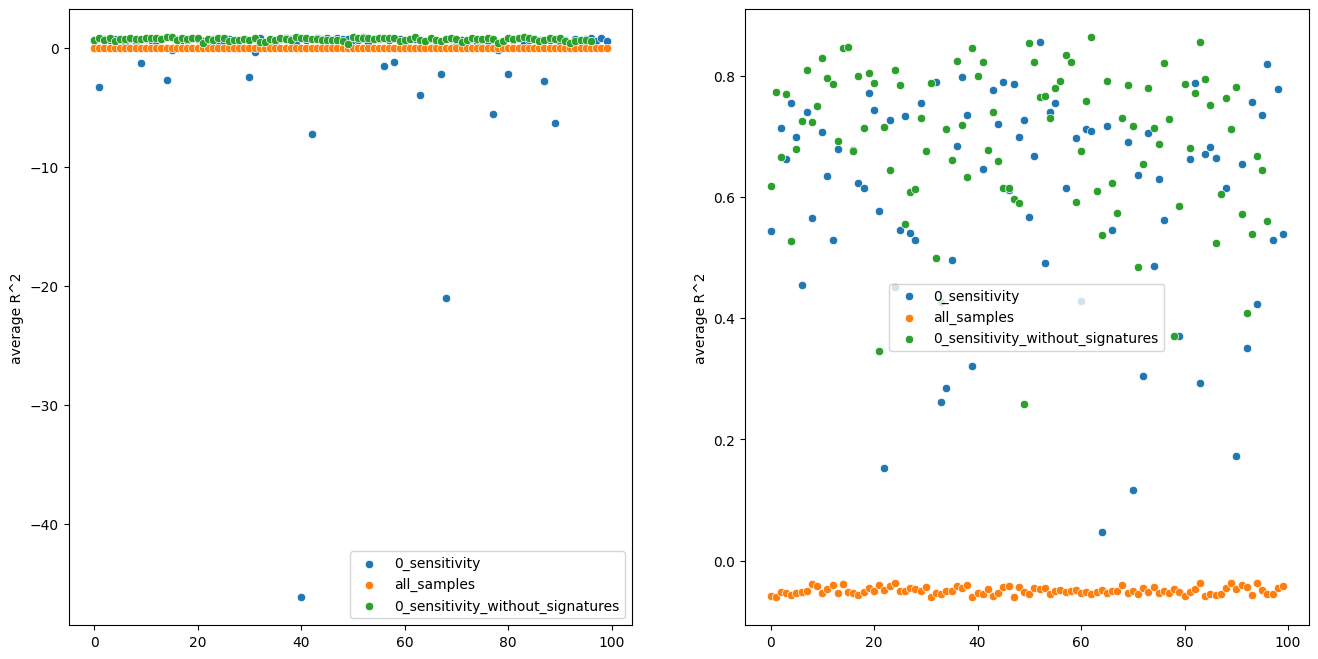

In [57]:
plt.figure(figsize=[16,8])
plt.subplot(1,2,1)
sns.scatterplot(a['average R^2'])
sns.scatterplot(b['average R^2'])
sns.scatterplot(c['average R^2'])
plt.legend(['0_sensitivity', 'all_samples', '0_sensitivity_without_signatures'])

plt.subplot(1,2,2)
sns.scatterplot(a[a['average R^2'] > 0]['average R^2'])
sns.scatterplot(b['average R^2'])
sns.scatterplot(c['average R^2'])
plt.legend(['0_sensitivity', 'all_samples', '0_sensitivity_without_signatures'])

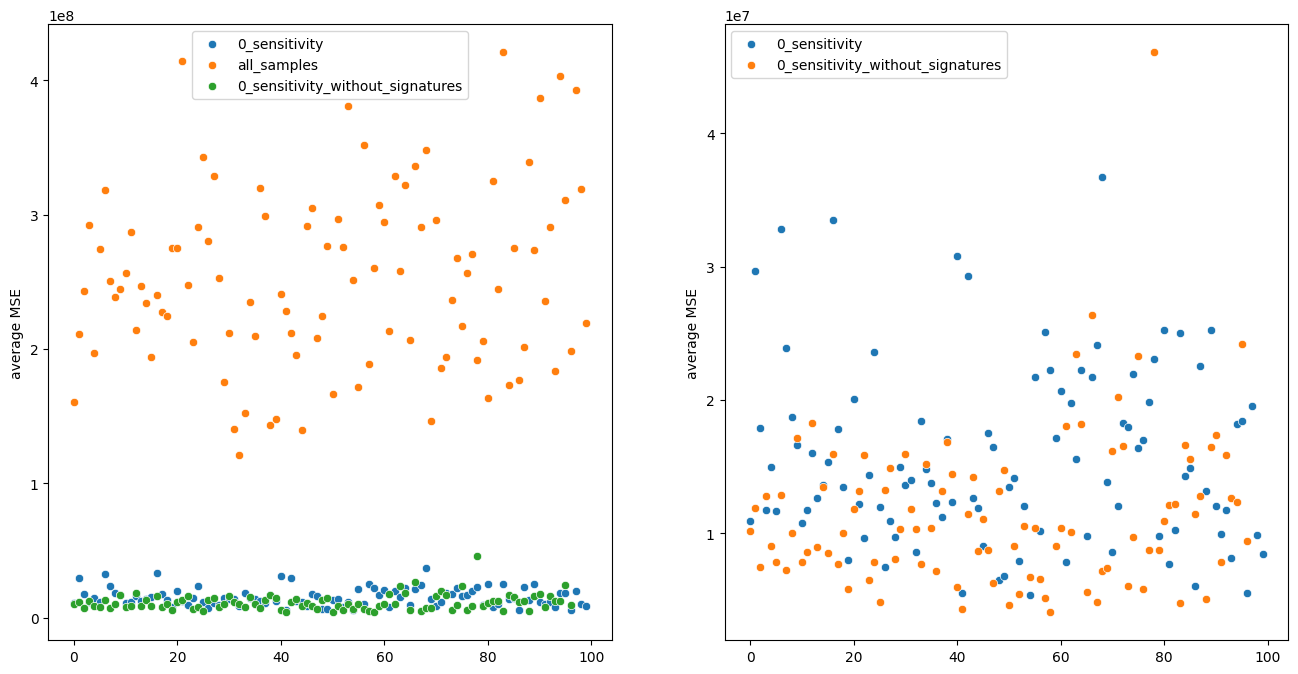

In [62]:
plt.figure(figsize=[16,8])
plt.subplot(1,2,1)
sns.scatterplot(a['average MSE'])
sns.scatterplot(b['average MSE'])
sns.scatterplot(c['average MSE'])
plt.legend(['0_sensitivity', 'all_samples', '0_sensitivity_without_signatures'])

plt.subplot(1,2,2)
sns.scatterplot(a['average MSE'])
sns.scatterplot(b[b['average MSE']< 100000000]['average MSE'])
sns.scatterplot(c['average MSE'])
plt.legend(['0_sensitivity', '0_sensitivity_without_signatures'])

### Check to see the number of samples per signature

In [40]:
seed = np.random.randint(1, 100000)
np.random.seed(seed=seed)
X_train, X_test, y_bin_train, y_bin_test, y_exp_train, y_exp_test = train_test_split(
    mutation_count, mutation_count_bin, signature_exposure, train_size=train_size,
)
x = pd.DataFrame({
    "total_in_dataset": np.sum(mutation_count_bin, axis=0),
    "total_in_train": np.sum(y_bin_train, axis=0)
})
x["dataset/train_ratio"] = x["total_in_train"] / x["total_in_dataset"]
x

,total_in_dataset,total_in_train,dataset/train_ratio
0,17453,13954,0.799519
1,15444,12305,0.796750
2,10852,8660,0.798010
3,9929,7884,0.794038
4,12426,9916,0.798004
5,14014,11219,0.800557
6,5526,4416,0.799131
7,7951,6356,0.799396
8,7355,5906,0.802991
9,6710,5353,0.797765


## Other models

### Simple linear Regressor with the mutation count accounted for the signature probability distribution

In [41]:
signature_exposure = pd.read_csv('../simulations/ground_truth/exposures.csv').iloc[:,1:].values  # N x 29
X_train, X_test, y_bin_train, y_bin_test, y_exp_train, y_exp_test = train_test_split(
            mutation_count @ signature_prob_distribution.T, mutation_count_bin, signature_exposure, random_state = seed, train_size=train_size,
        )

NameError: name 'signature_prob_distribution' is not defined

In [ ]:
pes_2 = PredictExposureWith0Sensitivity(LinearRegression())
regressors = pes_2.fit(X_train, y_bin_train, y_exp_train)
r2_2,mse_2,pred_2 = pes_2.evaluate(regressors, X_test, y_bin_test, y_exp_test)

In [ ]:
print_stats(r2_2,mse_2)

### ElasticNet

In [ ]:
from sklearn.linear_model import ElasticNet
pes_2 = PredictExposureWith0Sensitivity(ElasticNet(random_state=seed))
regressors = pes_2.fit(X_train, y_bin_train, y_exp_train)
r2_2,mse_2,pred_2 = pes_2.evaluate(regressors, X_test, y_bin_test, y_exp_test)

In [ ]:
print_stats(r2_2,mse_2)

### Simple linear Regressor with the mutation count accounted for the signature probability distribution and tissue sample

In [ ]:
from sklearn.preprocessing import LabelEncoder
tissues = pd.read_csv('../simulations/ground_truth/tumor_site.csv').iloc[:,1:-1].values
encoder = LabelEncoder()
tissues_encoded = pd.DataFrame(encoder.fit_transform(tissues))

In [ ]:
X_train, X_test, y_bin_train, y_bin_test, y_exp_train, y_exp_test = train_test_split(
            np.hstack([mutation_count @ signature_prob_distribution.T,tissues_encoded]), mutation_count_bin, signature_exposure, random_state = seed, train_size=train_size,
        )

In [ ]:
pes_3 = PredictExposureWith0Sensitivity(LinearRegression())
regressors = pes_3.fit(X_train, y_bin_train, y_exp_train)
r2_3,mse_3,pred_3 = pes_3.evaluate(regressors, X_test, y_bin_test, y_exp_test)

In [ ]:
print_stats(r2_3, mse_3)

In [ ]:
seed
# 8070

In [ ]:
pes = PredictExposureWith0Sensitivity(LinearRegression())
regressors = pes.fit(X_train, y_bin_train, y_exp_train)
r2,mse,pred = pes.evaluate(regressors, X_test, y_bin_test, y_exp_test)
print_stats(r2,mse)